In [1]:
from google.colab import files
uploaded = files.upload()

Saving Job Posting.csv to Job Posting.csv


## Load Dataset into Pandas

In [2]:
import pandas as pd



# Load dataset
df = pd.read_csv('Job Posting.csv', encoding='latin1')

# Show first rows
df.head()

,Website Domain,Ticker,Job Opening Title,Job Opening URL,First Seen At,Last Seen At,Location,Location Data,Category,Seniority,...,Description,Salary,Salary Data,Contract Types,Job Status,Job Language,Job Last Processed At,O*NET Code,O*NET Family,O*NET Occupation Name
0,bosch.com,NaN,IN_RBAI_Assistant Manager_Dispensing Process E...,https://jobs.smartrecruiters.com/BoschGroup/74...,2024-05-29T19:59:45Z,2024-07-31T14:35:44Z,"Indiana, United States","[{""city"":null,""state"":""Indiana"",""zip_code"":nul...","engineering, management, support",manager,...,**IN\_RBAI\_Assistant Manager\_Dispensing Proc...,NaN,"{""salary_low"":null,""salary_high"":null,""salary_...",full time,closed,en,2024-08-02T14:47:55Z,43-1011.00,Office and Administrative Support,First-Line Supervisors of Office and Administr...
1,bosch.com,NaN,Professional Internship: Hardware Development ...,https://jobs.smartrecruiters.com/BoschGroup/74...,2024-05-04T01:00:12Z,2024-07-29T17:46:16Z,"Delaware, United States","[{""city"":null,""state"":""Delaware"",""zip_code"":nu...",internship,non_manager,...,**Professional Internship: Hardware Developmen...,NaN,"{""salary_low"":null,""salary_high"":null,""salary_...","full time, internship, m/f",closed,en,2024-07-31T17:50:07Z,17-2061.00,Architecture and Engineering,Computer Hardware Engineers
2,zf.com,NaN,Process Expert BMS Production,https://jobs.zf.com/job/Shenyang-Process-Exper...,2024-04-19T06:47:24Z,2024-05-16T02:25:08Z,China,"[{""city"":null,""state"":null,""zip_code"":null,""co...",engineering,non_manager,...,ZF is a global technology company supplying sy...,NaN,"{""salary_low"":null,""salary_high"":null,""salary_...",NaN,closed,en,2024-05-18T02:32:04Z,51-9141.00,Production,Semiconductor Processing Technicians
3,bosch.com,NaN,DevOps Developer with Python for ADAS Computin...,https://jobs.smartrecruiters.com/BoschGroup/74...,2024-08-16T10:20:37Z,2024-08-22T11:14:49Z,Romania,"[{""city"":null,""state"":null,""zip_code"":null,""co...","information_technology, software_development",non_manager,...,**DevOps Developer with Python for ADAS Comput...,NaN,"{""salary_low"":null,""salary_high"":null,""salary_...",full time,closed,en,2024-08-23T00:33:30Z,15-1252.00,Computer and Mathematical,Software Developers
4,bosch.com,NaN,Senior Engineer Sales - Video Systems and Solu...,https://jobs.smartrecruiters.com/BoschGroup/74...,2024-07-01T17:31:20Z,2024-08-01T05:11:33Z,India,"[{""city"":null,""state"":null,""zip_code"":null,""co...","engineering, sales",non_manager,...,**Senior Engineer Sales - Video Systems and So...,NaN,"{""salary_low"":null,""salary_high"":null,""salary_...",full time,closed,en,2024-08-02T19:03:16Z,41-9031.00,Sales and Related,Sales Engineers


## Dataset Check

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9919 entries, 0 to 9918
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Website Domain         9919 non-null   object 
 1   Ticker                 0 non-null      float64
 2   Job Opening Title      9919 non-null   object 
 3   Job Opening URL        9919 non-null   object 
 4   First Seen At          9919 non-null   object 
 5   Last Seen At           9919 non-null   object 
 6   Location               9508 non-null   object 
 7   Location Data          9919 non-null   object 
 8   Category               8250 non-null   object 
 9   Seniority              9919 non-null   object 
 10  Keywords               7646 non-null   object 
 11  Description            9807 non-null   object 
 12  Salary                 576 non-null    object 
 13  Salary Data            9919 non-null   object 
 14  Contract Types         8004 non-null   object 
 15  Job 

In [4]:
df.isnull().sum()

,0
Website Domain,0
Ticker,9919
Job Opening Title,0
Job Opening URL,0
First Seen At,0
Last Seen At,0
Location,411
Location Data,0
Category,1669
Seniority,0


## important columns

In [5]:
df = df[[
    "Job Opening Title",
    "Location",
    "Category",
    "Seniority",
    "Description",
    "Salary",
    "First Seen At",
    "Job Status",
    "O*NET Occupation Name"
]]

## Rename columns

In [6]:
df.columns = [
    "job_title",
    "location",
    "category",
    "seniority",
    "description",
    "salary",
    "first_seen",
    "job_status",
    "occupation"
]

## Convert dates

In [7]:
df["first_seen"] = pd.to_datetime(df["first_seen"], errors="coerce")

## Remove empty rows

In [8]:
df = df.dropna(subset=["job_title", "location", "description"])

In [9]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 9445 entries, 0 to 9918
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   job_title    9445 non-null   object             
 1   location     9445 non-null   object             
 2   category     7872 non-null   object             
 3   seniority    9445 non-null   object             
 4   description  9445 non-null   object             
 5   salary       546 non-null    object             
 6   first_seen   9445 non-null   datetime64[ns, UTC]
 7   job_status   6463 non-null   object             
 8   occupation   9443 non-null   object             
dtypes: datetime64[ns, UTC](1), object(8)
memory usage: 737.9+ KB


,job_title,location,category,seniority,description,salary,first_seen,job_status,occupation
0,IN_RBAI_Assistant Manager_Dispensing Process E...,"Indiana, United States","engineering, management, support",manager,**IN\_RBAI\_Assistant Manager\_Dispensing Proc...,NaN,2024-05-29 19:59:45+00:00,closed,First-Line Supervisors of Office and Administr...
1,Professional Internship: Hardware Development ...,"Delaware, United States",internship,non_manager,**Professional Internship: Hardware Developmen...,NaN,2024-05-04 01:00:12+00:00,closed,Computer Hardware Engineers
2,Process Expert BMS Production,China,engineering,non_manager,ZF is a global technology company supplying sy...,NaN,2024-04-19 06:47:24+00:00,closed,Semiconductor Processing Technicians
3,DevOps Developer with Python for ADAS Computin...,Romania,"information_technology, software_development",non_manager,**DevOps Developer with Python for ADAS Comput...,NaN,2024-08-16 10:20:37+00:00,closed,Software Developers
4,Senior Engineer Sales - Video Systems and Solu...,India,"engineering, sales",non_manager,**Senior Engineer Sales - Video Systems and So...,NaN,2024-07-01 17:31:20+00:00,closed,Sales Engineers


# Deep Cleaning Layer

### Clean description text

In [10]:
import re

df["description"] = df["description"].str.replace(r"[*_\\]", " ", regex=True)
df["description"] = df["description"].str.replace(r"\s+", " ", regex=True).str.strip()

### Standardize location text

In [11]:
df["job_title"] = df["job_title"].str.replace(r"[_]", " ", regex=True)
df["job_title"] = df["job_title"].str.replace(r"\s+", " ", regex=True).str.strip()

### Standardize job title text

In [12]:
df["location"] = df["location"].str.strip().str.title()

In [13]:
df[["job_title", "location", "description"]].head(5)

,job_title,location,description
0,IN RBAI Assistant Manager Dispensing Process E...,"Indiana, United States",IN RBAI Assistant Manager Dispensing Process E...
1,Professional Internship: Hardware Development ...,"Delaware, United States",Professional Internship: Hardware Development ...
2,Process Expert BMS Production,China,ZF is a global technology company supplying sy...
3,DevOps Developer with Python for ADAS Computin...,Romania,DevOps Developer with Python for ADAS Computin...
4,Senior Engineer Sales - Video Systems and Solu...,India,Senior Engineer Sales - Video Systems and Solu...


#Country and Year Month Columns

In [14]:
df["country"] = df["location"].str.split(",").str[-1].str.strip()

df["year_month"] = df["first_seen"].dt.strftime("%Y-%m")

In [15]:
df[["location", "country", "first_seen", "year_month"]].head()

,location,country,first_seen,year_month
0,"Indiana, United States",United States,2024-05-29 19:59:45+00:00,2024-05
1,"Delaware, United States",United States,2024-05-04 01:00:12+00:00,2024-05
2,China,China,2024-04-19 06:47:24+00:00,2024-04
3,Romania,Romania,2024-08-16 10:20:37+00:00,2024-08
4,India,India,2024-07-01 17:31:20+00:00,2024-07


#City Column and Clean Job Status

In [16]:
df["city"] = df["location"].str.split(",").str[0].str.strip()
df["job_status"] = df["job_status"].fillna("Unknown").str.title().str.strip()

In [17]:
df[["location", "city", "country", "job_status"]].head(10)

,location,city,country,job_status
0,"Indiana, United States",Indiana,United States,Closed
1,"Delaware, United States",Delaware,United States,Closed
2,China,China,China,Closed
3,Romania,Romania,Romania,Closed
4,India,India,India,Closed
5,"Yokohama, Japan",Yokohama,Japan,Closed
6,"Lincolnton, North Carolina, 28092, United States",Lincolnton,United States,Closed
7,"Hanau, Germany",Hanau,Germany,Closed
8,"Campinas, Brazil",Campinas,Brazil,Unknown
9,"Charleston, South Carolina, 29418, United States",Charleston,United States,Closed


#Extract Skills from Job Descriptions

In [18]:
df["skill_python"] = df["description"].str.contains("python", case=False, na=False)
df["skill_sql"] = df["description"].str.contains("sql", case=False, na=False)
df["skill_excel"] = df["description"].str.contains("excel", case=False, na=False)
df["skill_powerbi"] = df["description"].str.contains("power bi", case=False, na=False)
df["skill_tableau"] = df["description"].str.contains("tableau", case=False, na=False)
df["skill_aws"] = df["description"].str.contains("aws", case=False, na=False)
df["skill_sap"] = df["description"].str.contains("sap", case=False, na=False)

In [41]:
skill_cols = [
    "skill_python",
    "skill_sql",
    "skill_excel",
    "skill_powerbi",
    "skill_aws",
    "skill_tableau",
    "skill_sap"
]

df[skill_cols] = df[skill_cols].astype(int)

In [37]:
df[[
    "job_title",
    "skill_python",
    "skill_sql",
    "skill_excel",
    "skill_powerbi",
    "skill_tableau"
]].head(10)

,job_title,skill_python,skill_sql,skill_excel,skill_powerbi,skill_tableau
0,IN RBAI Assistant Manager Dispensing Process E...,0,0,1,0,0
1,Professional Internship: Hardware Development ...,0,0,0,0,0
2,Process Expert BMS Production,0,0,0,0,0
3,DevOps Developer with Python for ADAS Computin...,1,0,0,0,0
4,Senior Engineer Sales - Video Systems and Solu...,0,0,0,0,0
5,[EM] ( EV/HEV Component System engineer),0,0,0,0,0
6,Controls Technician,0,0,0,0,0
7,Intern (m/f/d) Digital Business & eCommerce,0,0,0,0,0
8,ANALISTA DESENVOLVIMENTO SOFTWARE SR (ServiceN...,0,0,0,0,0
9,Production Technician - Bosch Charleston,0,0,1,0,1


#Standardize Seniority and Create Role Groups

In [20]:
df["seniority"] = df["seniority"].fillna("unknown").str.lower().str.strip()

In [21]:
def classify_role(title):
    title = str(title).lower()

    if "data" in title or "analyst" in title:
        return "Data / Analytics"
    elif "engineer" in title or "developer" in title:
        return "Engineering / IT"
    elif "manager" in title or "lead" in title:
        return "Management"
    elif "finance" in title or "account" in title:
        return "Finance"
    elif "hr" in title or "recruit" in title:
        return "HR / Talent"
    elif "sales" in title or "marketing" in title:
        return "Sales / Marketing"
    else:
        return "Other"

df["role_category"] = df["job_title"].apply(classify_role)

In [22]:
df[["job_title", "seniority", "role_category"]].head(10)

,job_title,seniority,role_category
0,IN RBAI Assistant Manager Dispensing Process E...,manager,Engineering / IT
1,Professional Internship: Hardware Development ...,non_manager,Other
2,Process Expert BMS Production,non_manager,Other
3,DevOps Developer with Python for ADAS Computin...,non_manager,Engineering / IT
4,Senior Engineer Sales - Video Systems and Solu...,non_manager,Engineering / IT
5,[EM] ( EV/HEV Component System engineer),non_manager,Engineering / IT
6,Controls Technician,non_manager,Other
7,Intern (m/f/d) Digital Business & eCommerce,non_manager,Other
8,ANALISTA DESENVOLVIMENTO SOFTWARE SR (ServiceN...,non_manager,Other
9,Production Technician - Bosch Charleston,non_manager,Other


#Monthly Hiring Trend Analysis

In [23]:
monthly_trend = df.groupby("year_month").size().reset_index(name="job_count")
monthly_trend
monthly_trend = monthly_trend.sort_values("year_month")
monthly_trend

,year_month,job_count
0,2024-03,1081
1,2024-04,1897
2,2024-05,1901
3,2024-06,1479
4,2024-07,1585
5,2024-08,1352
6,2024-09,150


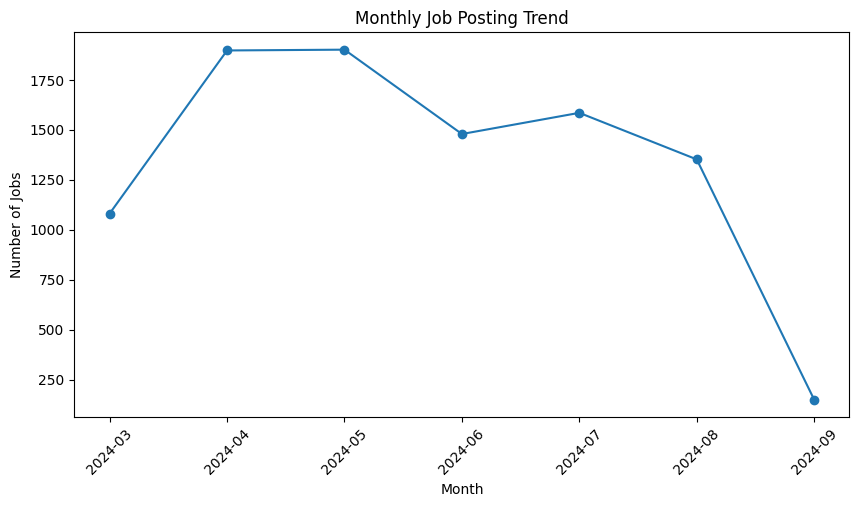

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_trend["year_month"], monthly_trend["job_count"], marker="o")
plt.title("Monthly Job Posting Trend")
plt.xlabel("Month")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.show()

#Export Power BI Ready Dataset

In [42]:
fact_jobs = df[[
    "job_title",
    "location",
    "city",
    "country",
    "category",
    "seniority",
    "job_status",
    "first_seen",
    "year_month",
    "role_category",
    "skill_python",
    "skill_sql",
    "skill_excel",
    "skill_powerbi",
    "skill_aws",
    "skill_tableau",
    "skill_sap"
]].copy()

In [43]:
fact_jobs.to_csv("fact_jobs_with_skills.csv", index=False)

In [44]:
from google.colab import files
files.download("fact_jobs_with_skills.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
skill_summary = pd.DataFrame({
    "skill": ["Python", "SQL", "Excel", "Power BI", "Tableau", "AWS", "SAP"],
    "demand_rate": [
        df["skill_python"].mean(),
        df["skill_sql"].mean(),
        df["skill_excel"].mean(),
        df["skill_powerbi"].mean(),
        df["skill_tableau"].mean(),
        df["skill_aws"].mean(),
        df["skill_sap"].mean()
    ]
})

In [27]:
monthly_trend = df.groupby("year_month").size().reset_index(name="job_count")
monthly_trend = monthly_trend.sort_values("year_month")

In [28]:
canada_df = df[df["country"].str.lower() == "canada"].copy()

In [29]:
fact_jobs.to_csv("fact_jobs.csv", index=False)
skill_summary.to_csv("skill_summary.csv", index=False)
monthly_trend.to_csv("monthly_trend.csv", index=False)
canada_df.to_csv("canada_jobs.csv", index=False)